# Deep Learning a Stochastic Volatility Surface

Author: Sebastien Gurrieri, sebgur@gmail.com

The purpose of this notebook is to provide a simple demo of the training of DNNs to fit implied volatility surfaces within [SDevPy](https://pypi.org/project/sdevpy/). This library was recently released and is designed to simplify the process of generating datasets, training models and testing them, currently applied to the calibration of interest rate implied volatility surfaces.

The principles at play here have been introduced and illustrated in a number of references. [[Hernandez 2016]](https://www.risk.net/media/download/952386/download) train a network to learn the model parameters as functions of the market prices for the Hull-White model ("inverse map"). [[Horvath et al. 2019]](https://arxiv.org/abs/1901.09647) prefer to learn the prices as functions of the model parameters ("direct map"), and apply this strategy to a number of stochastic volatility surfaces, including the rough Bergomi model. [McGhee 2018](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3288882) uses a similar approach to learn the SABR model. [Kienitz et al. 2021](https://www.youtube.com/watch?v=48QpXv1VTl8) have extended these ideas to other stochastic volatility surfaces such as Free-Boundary SABR, ZABR and Heston.

The overarching idea behind these references is that the neural network could be used as a replacement for a traditional valuation method to price vanilla options (direct map) or possibly to infer the model parameters from option prices (inverse map). Traditional methods such as analytical expressions may not be available for certain complex models. For these models, only PDE or Monte-Carlo simulations would allow us to calculate prices for the purpose of model calibration, but optimization on PDE or MC is exceedingly costly. The neural network can then be used to off-load the calculation time to the training phase, while the on-line calibration can be performed on the trained network very quickly.

Our purpose in [SDevPy](https://pypi.org/project/sdevpy/) is to create a python framework to easily develop those ideas and share datasets as well as trained networks. Here we start with the direct map, in a very similar fashion to the work by [Kienitz et al. 2021](https://www.youtube.com/watch?v=48QpXv1VTl8) and [McGhee 2018](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3288882). The library has a number of built-in methods to generate sample datasets and train the networks for the chosen models, which include SABR (Hagan), No-Arbitrage SABR, Free-Boundary SABR, ZABR and Heston. It can also easily download sample datasets and use pre-trained models from our [github repository](https://github.com/sebgur/SDev.Python) and [Kaggle for larger datasets](https://www.kaggle.com/sebastiengurrieri/datasets).

Generation of samples has been covered in a [previous notebook](https://colab.research.google.com/drive/1-0vRa31xcMwe8iE_U7cZATiTis17oFxL?usp=sharing). In the work here, the user may choose to:
* train a network from scratch (and test it on provided samples) or
* download a pre-trained network and test it on provided samples.

This is the preliminary step towards other goals we have in mind. Namely, we think that it would be valuable to develop the inverse map for these models but also bring this work to more "complex" models such as stochastic local vol multi-factor Cheyette, and we hope that the present framework can pave the way in this direction. The saved models have been trained with various amounts of efforts and on various amounts of data, ranging from 500k to 2 million samples. As a proof of concept we spent more time on the Hagan SABR model for which it was obviously easier to generate millions of samples, but since the shapes to learn are similar in other models, we think that, provided the sample datasets are clean, similar accuracies should be reachable on the other models. Obtaining clean datasets is therefore key. We use Monte-Carlo simulation for ease of implementation, but this leads to very slow generation and noisy data. PDEs would surely offer cleaner data for faster runtime. See [Kienitz et al. 2021](https://www.youtube.com/watch?v=48QpXv1VTl8) for materials on SABR-like PDEs.

### TODO
* Make base class for LearningModels with Keras and PyTorch subclasses
* Write PyTorch LearningModel wrapper
* Introduce scalers (same way as Keras)
* Check history viewing is working
* Check restart from trained model
* Train and save full model
* Refresh inverse
* Write diagnostics on gradient (vanishing?)
for name, param in torch_model.named_parameters():
    if param.grad is not None:
        print(name, param.grad.norm().item())

In [ ]:
# Import relevant modules
import os
from pathlib import Path
from datetime import datetime
import numpy as np
from platform import python_version
import matplotlib.pyplot as plt
import sdevpy as sd
from sdevpy.utilities import filemanager
from sdevpy.utilities.timer import Stopwatch
from sdevpy.volatility.mlsurfacegen import stovolfactory
from sdevpy.machinelearning import datasets
from sdevpy.machinelearning.pytorch.topology import compose_model
from sdevpy.volatility.impliedvol.optionsurface import plot_transform_surface
from sdevpy.maths.metrics import bps_rmse


print("Python version: " + python_version())
print("NumPy version: " + np.__version__)
print("SDevPy version: " + sd.__version__)
project_path = Path(os.environ.get('SDEVPY_DATA', Path.home() / 'sdevpy'))

Python version: 3.14.0
NumPy version: 2.3.5
SDevPy version: 1.2


## 1) Set runtime configuration


In [3]:
# Global settings
model_type = "SABR" # SABR, McSABR, FbSABR, McZABR, McHeston
model_id = model_type # Pre-trained model ID, may differ from model_type
use_trained = False
download_models = False # Only used when USE_TRAINED is True
download_datasets = False # Use when already created/downloaded
train = True
if use_trained is False and train is False:
    raise RuntimeError("When not using pre-trained models, a new model must be trained")

n_samples = 50_000 # Number of samples to read from sample files
train_percent = 0.90 # Proportion of dataset used for training (rest used for test)
epochs = 100
batch_size = 1000

# For comparison to reference values (accuracy of reference)
# n_mc = 100 * 1000 # 100 * 1000
# points_per_year = 25 # 25

print(">> Set up runtime configuration")
print(f"> Chosen model: {model_type}")
if use_trained:
    print(f"> Pre-trained model ID: {model_id}")

print(f"Number of samples in dataset: {n_samples:,}")
print(f"> Project folder: {project_path}")

dataset_path = project_path / "datasets" / "stovol" / "direct" / model_type
print(f"> Data folder: {dataset_path}")
data_file = project_path / "datasets" / "stovol" / "direct" / "train.tsv"
print(f"> Training data file (created): {data_file}")

model_path = project_path / "models" / "stovol" / "direct" / model_type
model_path.mkdir(parents=True, exist_ok=True)
print(f"> Model folder: {model_path}")

# Select the model
generator = stovolfactory.set_generator(model_type) #, num_mc=n_mc, points_per_year=points_per_year)

>> Set up runtime configuration
> Chosen model: SABR
Number of samples in dataset: 50,000
> Project folder: C:\temp\sdevpy
> Data folder: C:\temp\sdevpy\datasets\stovol\direct\SABR
> Training data file (created): C:\temp\sdevpy\datasets\stovol\direct\train.tsv
> Model folder: C:\temp\sdevpy\models\stovol\direct\SABR


## 2) Prepare the datasets

Datasets need to be read even if we do not train, as we are then going to evaluate the performance of a trained model loaded from a saved state and applied to the dataset.


In [8]:
if use_trained and download_models:
    url = 'https://github.com/sebgur/SDev.Python/raw/main/models/stovol/models.zip'
    print("> Downloading and unzipping models from: " + url)
    filemanager.download_unzip(url, model_path)

In [9]:
if download_datasets:
    url = 'https://github.com/sebgur/SDev.Python/raw/main/datasets/stovol/datasets.zip'
    print("> Downloading and unzipping datasets from: " + url)
    filemanager.download_unzip(url, dataset_path)

In [4]:
# Datasets are read and split into training and test sets. This split is only useful
# in case of training, but is always down for simplicity.
print(">> Preparing datasets")
# Retrieve data from dataset folder
print(f"> Requested {n_samples:,} samples")
datasets.retrieve_data(dataset_path, n_samples, shuffle=True, export_file=data_file)
print(f"> Exporting dataset to file: {data_file}")

print(f"> Reading dataset from: {data_file}")
x_set, y_set, data_df = generator.retrieve_datasets(data_file, shuffle=True)
input_dim = x_set.shape[1]
output_dim = y_set.shape[1]
print("> Input dimension: " + str(input_dim))
print("> Output dimension: " + str(output_dim))
print("> Dataset extract")
print(data_df.head())
# Split into training and test sets
TRS = train_percent * 100
print(f"> Splitting between training set ({TRS:.2f}%) and test set ({100 - TRS:.2f}%)")
x_train, y_train, x_test, y_test = datasets.prepare_sets(x_set, y_set, train_percent)

>> Preparing datasets
> Requested 50,000 samples
> Exporting dataset to file: C:\temp\sdevpy\datasets\stovol\direct\train.tsv
> Reading dataset from: C:\temp\sdevpy\datasets\stovol\direct\train.tsv
> Input dimension: 7
> Output dimension: 1
> Dataset extract
             Ttm         K         F     LnVol      Beta        Nu       Rho  \
21014  14.720569  0.028275  0.013599  0.118790  0.450814  0.255529 -0.387604   
16759  29.949625 -0.025002  0.002280  0.484205  0.443071  0.377720 -0.429191   
45976   0.371407  0.025164  0.023929  0.161920  0.294235  0.931328 -0.228698   
10408  19.775756  0.035741  0.034611  0.140512  0.408354  0.380926 -0.130229   
17510   5.556917  0.020639  0.024205  0.127423  0.187534  0.958121  0.072987   

          Price      NVol  
21014  0.017629  0.005429  
16759  0.004943  0.006751  
45976  0.002827  0.008858  
10408  0.019847  0.010866  
17510  0.007657  0.009923  
> Splitting between training set (90.00%) and test set (10.00%)


## 3) Compose the learning model

If we load a pre-trained model (USE_TRAINED=True), we read its characteristics for display. However if we chose to start training a fresh new model, we need to specify its structure.

In [ ]:
if use_trained:
    raise NotImplementedError()
    # print(">> Loading pre-trained model")
    # model_path_name = model_path / model_id
    # print(f"> Loading pre-trained model from: {model_path_name}")
    # model = load_learning_model(model_path_name)
    # keras_model = model.model
    # HIDDEN_LAYERS = NUM_NEURONS = DROP_OUT = None
    # topology = model.topology_
    # if topology is not None:
    #     HIDDEN_LAYERS = topology['layers']
    #     NUM_NEURONS = topology['neurons']
    #     DROP_OUT = topology['dropout']
else:
    raise NotImplementedError()
    # print(">> Composing new model")
    # # Initialize the model
    # hidden_activations = ['softplus', 'softplus', 'softplus']
    # n_neurons = 64
    # dropout = 0.0
    # keras_model = compose_model(input_dim, output_dim, hidden_activations, n_neurons, dropout)
    # topology = { 'layers': hidden_activations, 'neurons': n_neurons, 'dropout': dropout}

    # model = LearningModel(keras_model)
    # model.topology_ = topology

# # Display topology
# print(f"> Hidden layer structure: {hidden_activations}")
# print(f"> Number of neurons per layer: {n_neurons}")
# print(f"> Drop-out rate: {dropout:.2f}")

>> Loading pre-trained model
> Loading pre-trained model from: /content/sdevpy/stovol/models/McZABR
> Hidden layer structure: ['softplus', 'softplus', 'softplus']
> Number of neurons per layer: 64
> Drop-out rate: 0.00


In [5]:
hidden_activations = ['softplus', 'softplus', 'softplus'] # relu, tanh, elu, selu, gelu, softplus
n_neurons = 16
dropout = 0.0

torch_model = compose_model(input_dim, output_dim, hidden_activations, n_neurons, dropout)

## 4) Training

If the user chose to train, training will start here by specifying the learning schedule in a custom class for which the learning rate starts at INIT_LR and decreases exponentially down to FINAL_LR. As a rule of thumb from trial and error, we find that for fresh training INIT_LR=1e-1 tends to produce good results, while for focusing accuracy of a pre-trained model, smaller learning rates around 1e-2 or 1e-3 are better.

We also implement a custom callback that periodically calculates the loss (RMSE) on the test set to watch for over-fitting.

At the end of the training, the model is saved under a new name. Note that we use our own wrapper (LearningModel) above the Keras model. It includes scalers and various additional functionalities for loading and saving.

In [7]:
# BPS RMSE loss
def bps_rmse_loss(pred, target):
    return 10000.0 * torch.sqrt(torch.mean((pred - target) ** 2))

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

if train:
    # Learning rate scheduler
    init_lr = 1.0e-2
    final_lr = 1.0e-4
    decay = 0.97
    decay_steps = 250
    epoch_sampling = 5

    # Send model to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch_model = torch_model.to(device)

    # Convert to tensors
    x_train_t = torch.tensor(x_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    x_test_t = torch.tensor(x_test, dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

    # DataLoader
    loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=batch_size, shuffle=True)

    # Optimizer and scheduler
    optimizer = torch.optim.Adam(torch_model.parameters(), lr=init_lr)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: max(decay ** (step / decay_steps), final_lr / init_lr))

    # Training history
    hist_epochs, hist_losses, hist_lr, sampled_epochs, test_losses = [], [], [], [], []

    print("<><><><><><><><> TRAINING START <><><><><><><><>")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size:,}")
    print(f"Training set size: {len(x_train_t):,}")
    print("<><><><><><><><><><><><><><><><><><><><><><><><>")

    trn_timer = Stopwatch("Training")
    trn_timer.trigger()

    for epoch in range(epochs):
        torch_model.train()
        epoch_loss = 0.0
        for batch_x, batch_y in loader:
            optimizer.zero_grad() # Reset the gradients
            pred = torch_model(batch_x) # Feed-forward
            loss = bps_rmse_loss(pred, batch_y) # Calculate loss
            loss.backward() # Propagate backwards
            optimizer.step() # Modify weights
            scheduler.step() # Evolve learning rate
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        current_lr = scheduler.get_last_lr()[0]
        hist_epochs.append(epoch)
        hist_losses.append(avg_loss)
        hist_lr.append(current_lr)

        if epoch % epoch_sampling == 0:
            torch_model.eval()
            with torch.no_grad():
                test_loss = bps_rmse_loss(torch_model(x_test_t), y_test_t).item()
            sampled_epochs.append(epoch)
            test_losses.append(test_loss)
            print(f"Epoch {epoch}/{epochs}")
            print(f"Loss: {avg_loss:.2f}, LR: {current_lr:.6f}, Test loss: {test_loss:.2f}")
            print("<><><><><><><><><><><><><><><><>")

    trn_timer.stop()
    trn_timer.print()

    # Save model weights
    now = datetime.now()
    dt_string = now.strftime("%Y%m%d-%H_%M_%S")
    save_path = model_path / (model_type + "_" + dt_string + ".pt")
    torch.save(torch_model.state_dict(), save_path)
    print(f"Saving model to: {save_path}")
    print("<><><><><><><><> TRAINING END <><><><><><><><>")

<><><><><><><><> TRAINING START <><><><><><><><>
Epochs: 100
Batch size: 1,000
Training set size: 45,000
<><><><><><><><><><><><><><><><><><><><><><><><>
Epoch 0/100
Loss: 1431.98, LR: 0.009945, Test loss: 205.34
<><><><><><><><><><><><><><><><>
Epoch 5/100
Loss: 77.04, LR: 0.009676, Test loss: 99.99
<><><><><><><><><><><><><><><><>
Epoch 10/100
Loss: 65.99, LR: 0.009415, Test loss: 65.70
<><><><><><><><><><><><><><><><>
Epoch 15/100
Loss: 59.91, LR: 0.009160, Test loss: 56.50
<><><><><><><><><><><><><><><><>
Epoch 20/100
Loss: 56.84, LR: 0.008912, Test loss: 66.40
<><><><><><><><><><><><><><><><>
Epoch 25/100
Loss: 54.96, LR: 0.008671, Test loss: 47.57
<><><><><><><><><><><><><><><><>
Epoch 30/100
Loss: 53.20, LR: 0.008437, Test loss: 69.75
<><><><><><><><><><><><><><><><>
Epoch 35/100
Loss: 51.14, LR: 0.008209, Test loss: 60.80
<><><><><><><><><><><><><><><><>
Epoch 40/100
Loss: 48.65, LR: 0.007987, Test loss: 44.24
<><><><><><><><><><><><><><><><>
Epoch 45/100
Loss: 48.38, LR: 0.007

## 5) Testing

The model, which may have simply been loaded or trained, is now evaluated on the training and test sets. We also use a specific point to display in charts the comparison between the model and the reference (on which it was trained, which may come from closed-form, PDE or MC). The chart comparison can be done on 3 possible variables (called TRANSFORM here): the prices, the Bachelier or Shifted Black-Scholes implied volatilities. Finally, if the model was trained here, we show the evolution of the training loss and learning schedule.

In [9]:
class TorchModelWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, x_np):
        self.model.eval()
        with torch.no_grad():
            x_t = torch.tensor(x_np, dtype=torch.float32).to(device)
            y_t = self.model(x_t)
        return y_t.cpu().numpy()

>> Analyse results
> RMSE(nvol) on training set: 31.55
> RMSE(nvol) on test set: 31.17
> Choosing a sample parameter set to display chart
> Calculating chart surface with reference model
> Calculating chart surface with trained model
> Ref-Mod RMSE(price): 23.61
Runtime(Reference surface calculation): 0.2s
Runtime(Model surface calculation): 0.2s


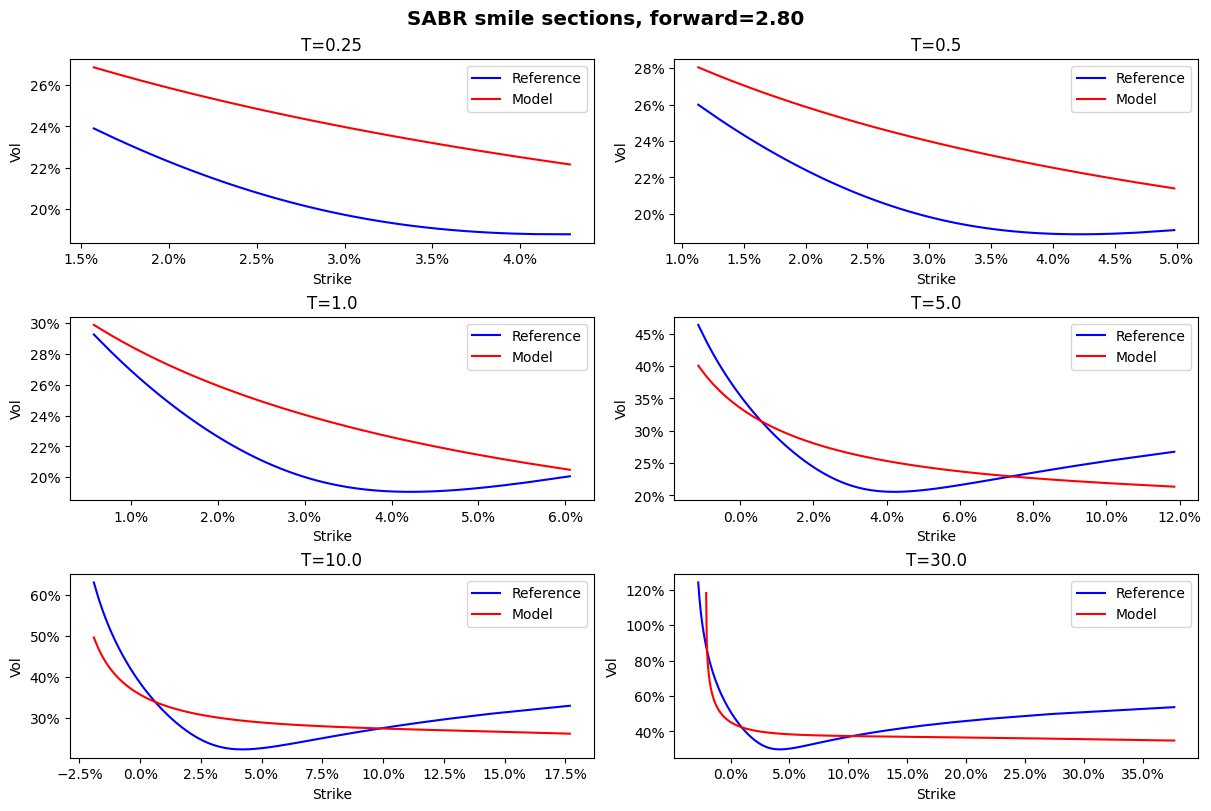

In [10]:
# Analyse results
print(">> Analyse results")

model = TorchModelWrapper(torch_model)

# Check performance
train_pred = model.predict(x_train)
train_rmse = bps_rmse(train_pred, y_train)
print(f"> RMSE(nvol) on training set: {train_rmse:,.2f}")

test_pred = model.predict(x_test)
test_rmse = bps_rmse(test_pred, y_test)
print(f"> RMSE(nvol) on test set: {test_rmse:,.2f}")

# Generate strike spread axis
print("> Choosing a sample parameter set to display chart")
n_strikes = 100
params = {'LnVol': 0.20, 'Beta': 0.5, 'Nu': 0.55, 'Rho': -0.25, 'Gamma': 0.7, 'Kappa': 1.0,
          'Theta': 0.03, 'Xi': 0.35}
fwd = 0.028

# Any number of expiries can be calculated, but for optimum display choose no more than 6
expiries = np.asarray([0.25, 0.50, 1.0, 5.00, 10.0, 30.0]).reshape(-1, 1)
n_expiries = expiries.shape[0]
method = 'Percentiles'
percents = np.linspace(0.01, 0.99, num=n_strikes)
percents = np.asarray([percents] * n_expiries)

strikes = generator.convert_strikes(expiries, percents, fwd, params, method)
are_calls = [[False] * n_strikes] * n_expiries # All puts

print("> Calculating chart surface with reference model")
timer_ref = Stopwatch("Reference surface calculation")
timer_ref.trigger()
ref_prices = generator.price_surface_ref(expiries, strikes, are_calls, fwd, params)
timer_ref.stop()

print("> Calculating chart surface with trained model")
timer_mod = Stopwatch("Model surface calculation")
timer_mod.trigger()
mod_prices = generator.price_surface_mod(model, expiries, strikes, are_calls, fwd, params)
timer_mod.stop()

print(f"> Ref-Mod RMSE(price): {bps_rmse(ref_prices, mod_prices):.2f}")

# Display timers
timer_ref.print()
timer_mod.print()

title = f"{model_type} smile sections, forward={fwd*100:.2f}"#,%\n parameters={params}"
transform = "ShiftedBlackScholes" # ShiftedBlackScholes, Bachelier, Price
plot_transform_surface(expiries, strikes, are_calls, fwd, ref_prices, mod_prices, title,
                       transform=transform)

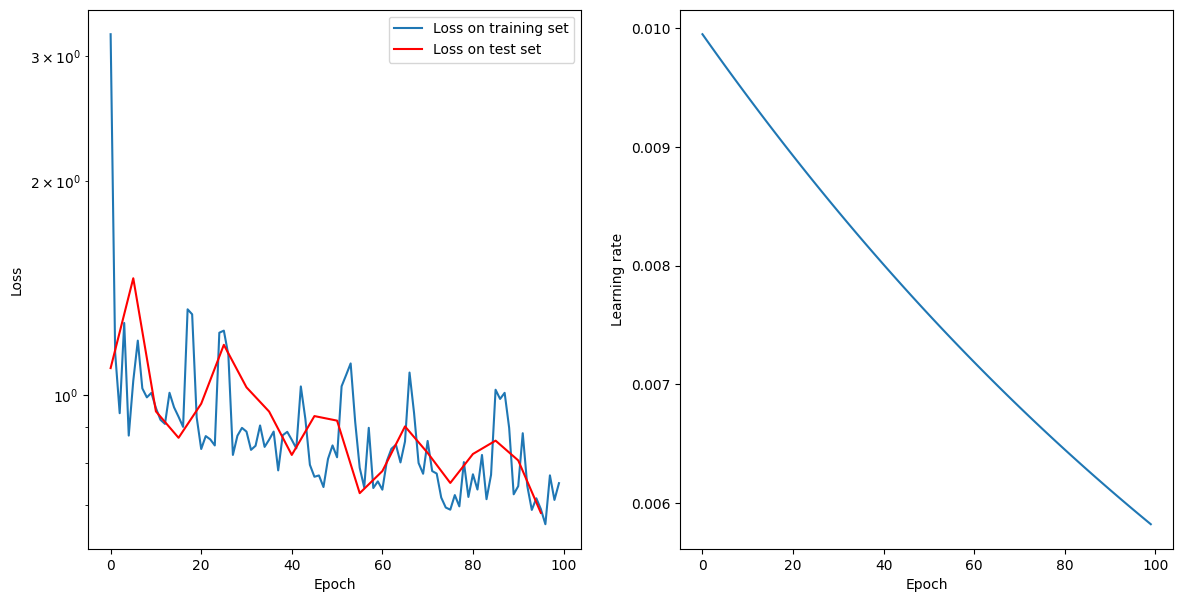

In [ ]:
# Show training history
if TRAIN:
    hist_epochs = callback.epochs
    hist_losses = callback.losses
    hist_lr = callback.learning_rates
    sampled_epochs = callback.sampled_epochs
    test_losses = callback.test_losses

    plt.figure(figsize=(14, 7))
    plt.subplots_adjust(hspace=0.40)

    plt.subplot(1, 2, 1)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale("log")
    plt.plot(hist_epochs, hist_losses, label='Loss on training set')
    plt.plot(sampled_epochs, test_losses, color='red', label='Loss on test set')
    plt.legend(loc='upper right')
    plt.subplot(1, 2, 2)
    plt.xlabel('Epoch')
    plt.ylabel('Learning rate')
    plt.plot(hist_epochs, hist_lr)

    plt.show()